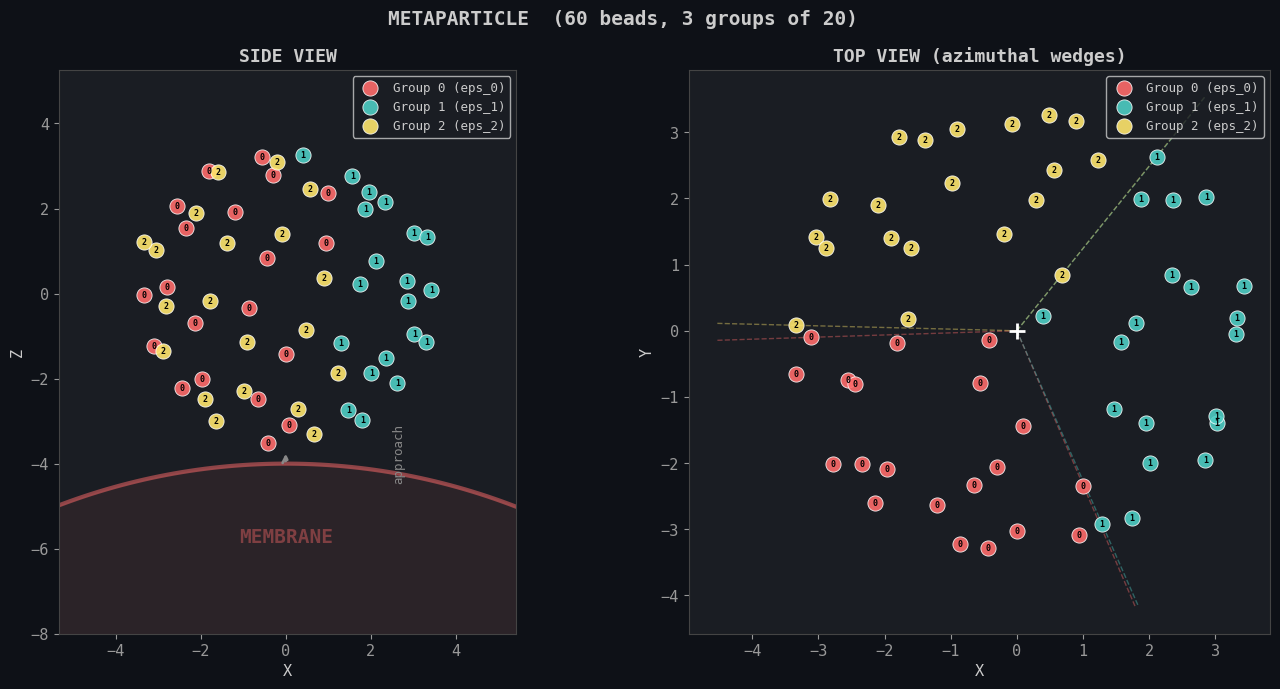

In [138]:
# METAPARTICLE: 3 azimuthal wedge groups colored
# Shows which group faces the membrane

import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from scipy.interpolate import griddata
from pathlib import Path

plt.rcParams.update({
    "figure.facecolor": "#0e1117",
    "axes.facecolor": "#1a1d23",
    "axes.edgecolor": "#444",
    "axes.labelcolor": "#ccc",
    "text.color": "#ccc",
    "xtick.color": "#999",
    "ytick.color": "#999",
    "grid.color": "#333",
    "grid.alpha": 0.4,
    "font.family": "monospace",
    "font.size": 11,
})

# Load bead group data
with open("bo_runs/bead_groups.json") as f:
    bg = json.load(f)

bead_info = bg["bead_info"]
coords = np.array([b["xyz"] for b in bead_info])
bead_groups = np.array([b["group"] for b in bead_info])

group_colors = ["#ff6b6b", "#4ecdc4", "#ffe66d"]
group_labels = ["Group 0 (eps_0)", "Group 1 (eps_1)", "Group 2 (eps_2)"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# --- LEFT: Side view (XZ) with membrane below ---
theta_arc = np.linspace(-0.6, 0.6, 100)
mem_radius = 15
mem_center_z = -mem_radius - 4
arc_x = mem_radius * np.sin(theta_arc)
arc_z = mem_center_z + mem_radius * np.cos(theta_arc)
ax1.fill_between(arc_x, arc_z, arc_z.min() - 2, color="#ff6b6b", alpha=0.08)
ax1.plot(arc_x, arc_z, color="#ff6b6b", lw=3, alpha=0.5)
ax1.text(0, arc_z.max() - 1.5, "MEMBRANE", ha="center", va="top",
         fontsize=14, color="#ff6b6b", alpha=0.4, fontweight="bold")

ax1.annotate("", xy=(0, arc_z.max() + 0.3), xytext=(0, coords[:, 2].min() - 0.5),
             arrowprops=dict(arrowstyle="->", color="#888", lw=2, ls="--"))
ax1.text(2.5, (arc_z.max() + coords[:, 2].min()) / 2, "approach",
         fontsize=9, color="#888", rotation=90, ha="left", va="center")

for g in range(3):
    mask = bead_groups == g
    ax1.scatter(coords[mask, 0], coords[mask, 2], c=group_colors[g],
                s=120, edgecolors="white", linewidths=0.6, label=group_labels[g],
                alpha=0.9, zorder=5)

for b in bead_info:
    ax1.text(b["xyz"][0], b["xyz"][2], str(b["group"]),
             fontsize=6, ha="center", va="center", color="black",
             fontweight="bold", zorder=6)

ax1.set_xlabel("X")
ax1.set_ylabel("Z")
ax1.set_title("SIDE VIEW", fontweight="bold", fontsize=13)
ax1.set_aspect("equal")
ax1.legend(fontsize=9, loc="upper right")
pad = 2
ax1.set_xlim(coords[:, 0].min() - pad, coords[:, 0].max() + pad)
ax1.set_ylim(arc_z.max() - 4, coords[:, 2].max() + pad)

# --- RIGHT: Top-down view (XY) with wedge boundaries ---
for g in range(3):
    mask = bead_groups == g
    ax2.scatter(coords[mask, 0], coords[mask, 1], c=group_colors[g],
                s=120, edgecolors="white", linewidths=0.6, label=group_labels[g],
                alpha=0.9, zorder=5)

for b in bead_info:
    ax2.text(b["xyz"][0], b["xyz"][1], str(b["group"]),
             fontsize=6, ha="center", va="center", color="black",
             fontweight="bold", zorder=6)

r_max = np.max(np.linalg.norm(coords[:, :2], axis=1)) * 1.3
for g in range(3):
    g_thetas = sorted([b["theta_deg"] for b in bead_info if b["group"] == g])
    theta_min = np.radians(g_thetas[0])
    theta_max = np.radians(g_thetas[-1])
    ax2.plot([0, r_max * np.cos(theta_min)], [0, r_max * np.sin(theta_min)],
             color=group_colors[g], ls="--", lw=1, alpha=0.4)
    ax2.plot([0, r_max * np.cos(theta_max)], [0, r_max * np.sin(theta_max)],
             color=group_colors[g], ls="--", lw=1, alpha=0.4)

ax2.plot(0, 0, "+", color="white", ms=12, mew=2)
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_title("TOP VIEW (azimuthal wedges)", fontweight="bold", fontsize=13)
ax2.set_aspect("equal")
ax2.legend(fontsize=9, loc="upper right")

fig.suptitle("METAPARTICLE  (60 beads, 3 groups of 20)",
             fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

In [139]:
# Load BO results
results_path = Path("bo_runs/bo_results.json")
with open(results_path) as f:
    results = json.load(f)

ok = [r for r in results if r.get("status") == "success"]
eps = np.array([r["epsilons"] for r in ok])
scores = np.array([r["objective"] for r in ok])
rR = np.array([r["radial_ratio"] for r in ok])
eval_ids = np.array([r["eval_id"] for r in ok])
n_initial = 10  # Sobol phase size

# Score normalization for display (scores can exceed 1.0 due to split bonus)
score_max = max(scores.max(), 1.0) if len(scores) > 0 else 1.0

# New scoring fields: solid angle coverage, n_contacts, depth
coverage = np.array([r.get("coverage", np.nan) for r in ok])
n_contacts = np.array([r.get("n_contacts", 0) for r in ok])
depth = np.array([r.get("depth", np.nan) for r in ok])
n_mem_clusters = np.array([r.get("n_membrane_clusters", 0) for r in ok])
has_coverage = ~np.isnan(coverage)

print(f"{len(ok)}/{len(results)} runs  |  "
      f"inside: {(rR < 1.0).sum()}  |  "
      f"outside: {(rR >= 1.0).sum()}  |  "
      f"best r/R: {rR.min():.3f}")
print(f"score = depth * (0.5 + 0.5 * coverage) * (1 + split_bonus)  |  "
      f"score range: [{scores.min():.3f}, {scores.max():.3f}]  |  "
      f"coverage data: {has_coverage.sum()}/{len(ok)} runs")

9/9 runs  |  inside: 5  |  outside: 4  |  best r/R: 0.406
score = depth * (0.5 + 0.5 * coverage) * (1 + split_bonus)  |  score range: [0.024, 1.115]  |  coverage data: 9/9 runs


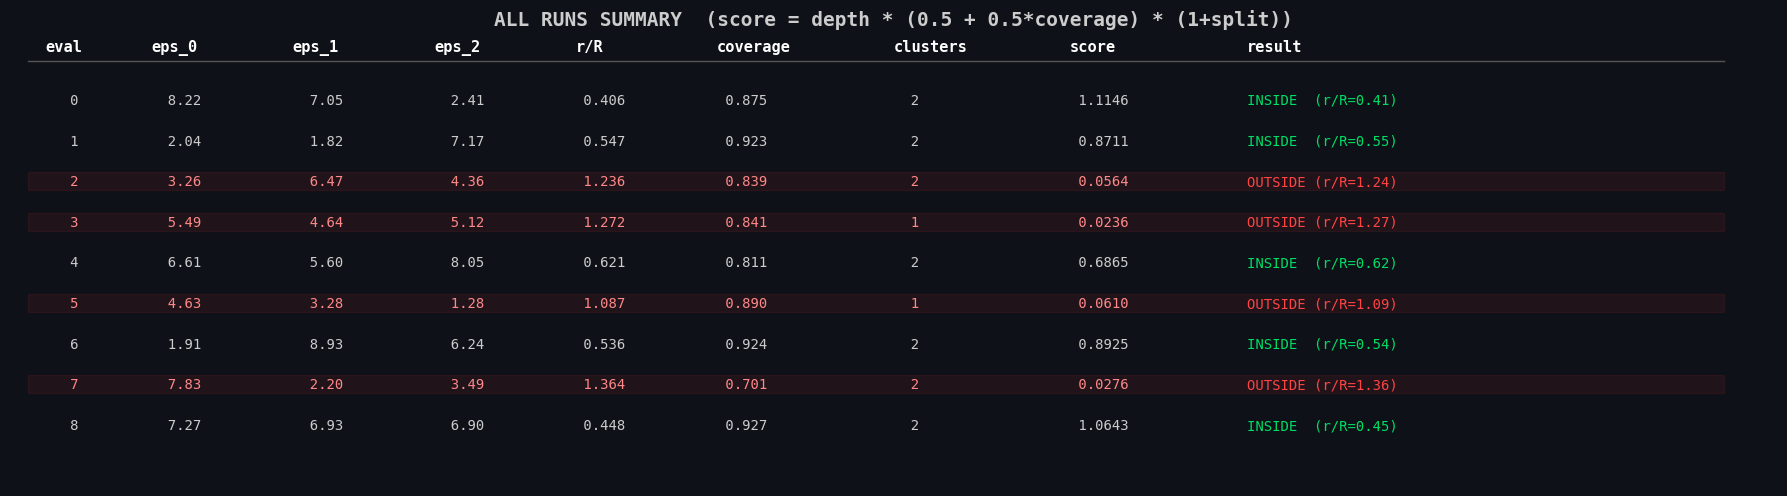

In [140]:
# SUMMARY TABLE: all runs at a glance
# Green = inside, red = failed (outside). Includes coverage + cluster info.

fig, ax = plt.subplots(figsize=(18, max(2, 0.4 * len(ok) + 1.5)))
ax.axis("off")

headers = ["eval", "eps_0", "eps_1", "eps_2", "r/R", "coverage", "clusters", "score", "result"]
col_x = [0.02, 0.08, 0.16, 0.24, 0.32, 0.40, 0.50, 0.60, 0.70]

# Header row
for x, h in zip(col_x, headers):
    ax.text(x, 1.0, h, fontsize=11, fontweight="bold", color="white",
            transform=ax.transAxes, va="top", family="monospace")
ax.plot([0.01, 0.97], [0.95, 0.95], color="#555", lw=1,
        transform=ax.transAxes, clip_on=False)

sorted_runs = sorted(ok, key=lambda r: r["eval_id"])
n = len(sorted_runs)

for i, r in enumerate(sorted_runs):
    y = 1.0 - (i + 1.5) / (n + 2)
    s = r["objective"]
    rr = r["radial_ratio"]
    e = r["epsilons"]
    cov = r.get("coverage", None)
    ncl = r.get("n_membrane_clusters", 0)

    inside = rr < 1.0

    if inside:
        row_color = "#00dd66"
        result_text = f"INSIDE  (r/R={rr:.2f})"
    else:
        row_color = "#ff4444"
        result_text = f"OUTSIDE (r/R={rr:.2f})"

    cov_str = f"{cov:.3f}" if cov is not None else "  -  "
    cl_str = f"{ncl}" if ncl else "-"

    vals = [
        f"{r['eval_id']:>4d}",
        f"{e[0]:>6.2f}",
        f"{e[1]:>6.2f}",
        f"{e[2]:>6.2f}",
        f"{rr:>6.3f}",
        f"{cov_str:>6s}",
        f"{cl_str:>3s}",
        f"{s:>7.4f}",
        result_text,
    ]

    for x, v in zip(col_x, vals):
        c = row_color if x == col_x[-1] else ("#ccc" if inside else "#ff8888")
        ax.text(x, y, v, fontsize=10, color=c,
                transform=ax.transAxes, va="center", family="monospace")

    if not inside:
        rect = plt.Rectangle((0.01, y - 0.02), 0.96, 0.04,
                              transform=ax.transAxes, color="#ff4444",
                              alpha=0.08, clip_on=False)
        ax.add_patch(rect)

ax.set_title("ALL RUNS SUMMARY  (score = depth * (0.5 + 0.5*coverage) * (1+split))",
             fontweight="bold", fontsize=14, pad=10)
plt.tight_layout()
plt.show()

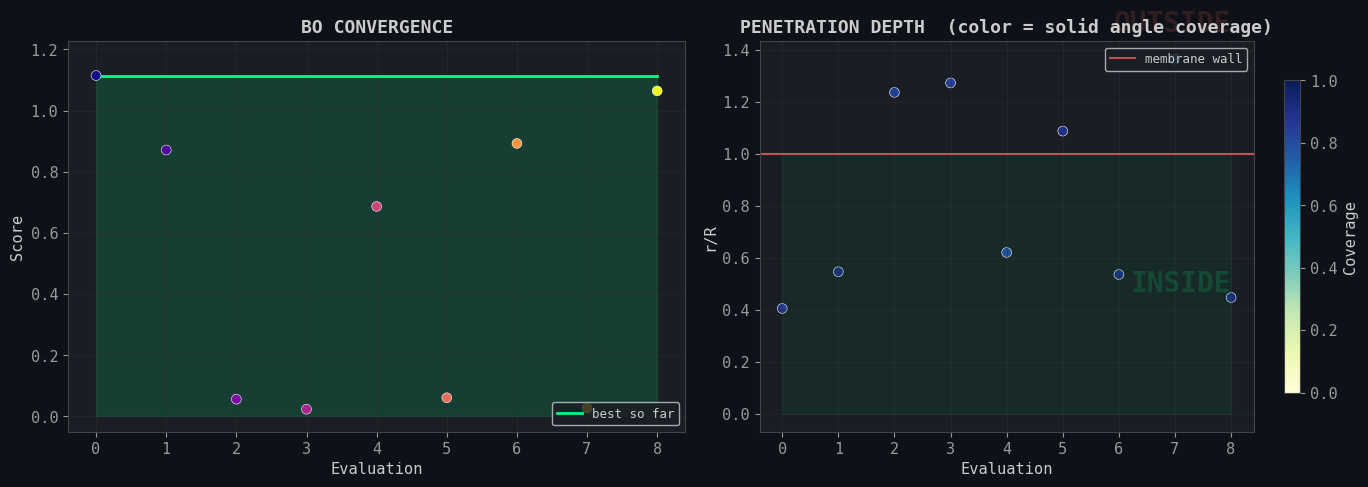

In [141]:
# 1. EXPLORATION TRAJECTORY

fig = plt.figure(figsize=(14, 5))

# Left: cumulative best + individual scores
ax1 = fig.add_subplot(121)
cum_best = np.maximum.accumulate(scores)

ax1.fill_between(eval_ids, 0, cum_best, alpha=0.15, color="#00ff88")
ax1.plot(eval_ids, cum_best, color="#00ff88", lw=2, label="best so far")
ax1.scatter(eval_ids, scores, c=np.arange(len(scores)), cmap="plasma",
            s=50, zorder=5, edgecolors="white", linewidths=0.4)

if len(eval_ids) > n_initial:
    ax1.axvline(n_initial - 0.5, color="#ff6b6b", ls="--", alpha=0.6)
    ax1.text(n_initial - 0.5, score_max * 1.02, "SOBOL | BO", ha="center",
             fontsize=8, color="#ff6b6b")

ax1.set_xlabel("Evaluation")
ax1.set_ylabel("Score")
ax1.set_title("BO CONVERGENCE", fontweight="bold", fontsize=13)
ax1.set_ylim(-0.05, score_max * 1.1)
ax1.legend(loc="lower right", fontsize=9)
ax1.grid(True)

# Right: r/R over time, colored by solid angle coverage
ax2 = fig.add_subplot(122)
sc = ax2.scatter(eval_ids, rR, c=coverage, cmap="YlGnBu", s=50,
                 edgecolors="white", linewidths=0.4, vmin=0, vmax=1)
ax2.axhline(1.0, color="#ff6b6b", ls="-", lw=1.5, alpha=0.7, label="membrane wall")
ax2.fill_between(eval_ids[[0, -1]], 0, 1, alpha=0.06, color="#00ff88")
ax2.text(eval_ids[-1], 0.5, "INSIDE", ha="right", va="center",
         fontsize=20, color="#00ff88", alpha=0.15, fontweight="bold")
ax2.text(eval_ids[-1], 1.5, "OUTSIDE", ha="right", va="center",
         fontsize=20, color="#ff6b6b", alpha=0.15, fontweight="bold")

ax2.set_xlabel("Evaluation")
ax2.set_ylabel("r/R")
ax2.set_title("PENETRATION DEPTH  (color = solid angle coverage)", fontweight="bold", fontsize=13)
ax2.legend(loc="upper right", fontsize=9)
ax2.grid(True)
fig.colorbar(sc, ax=ax2, label="Coverage", shrink=0.8)

plt.tight_layout()
plt.show()

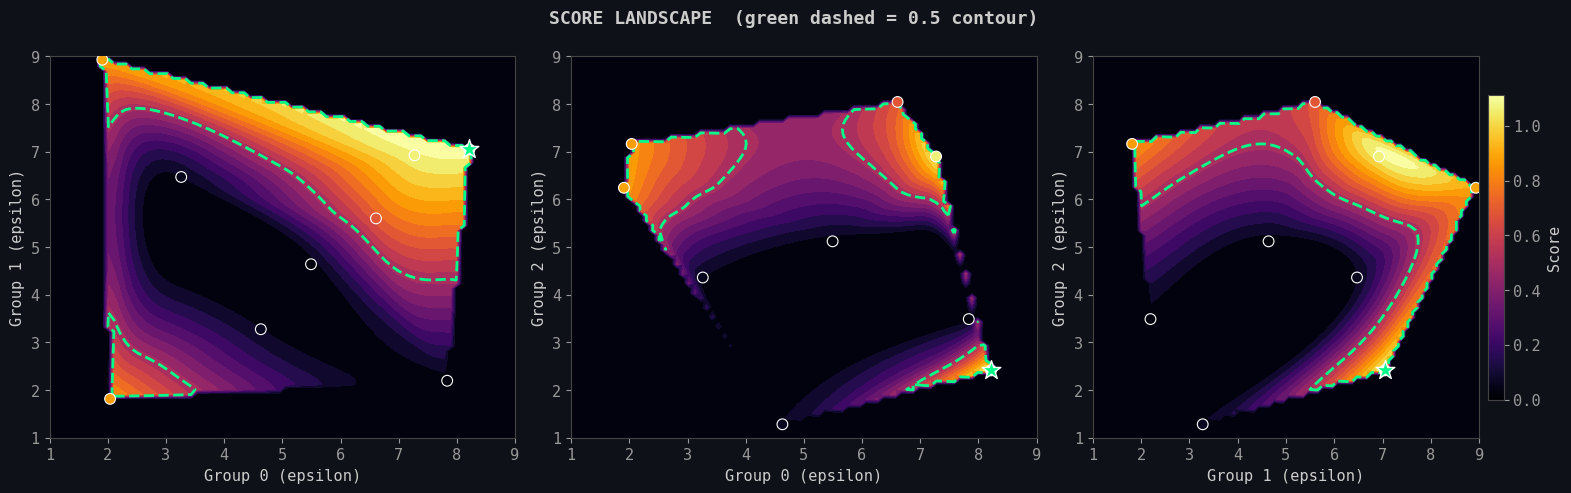

In [142]:
# 2. HEATMAPS: interpolated score landscape in epsilon space

pairs = [(0, 1, "Group 0", "Group 1"),
         (0, 2, "Group 0", "Group 2"),
         (1, 2, "Group 1", "Group 2")]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (i, j, li, lj) in zip(axes, pairs):
    xi = np.linspace(1, 9, 80)
    yi = np.linspace(1, 9, 80)
    XI, YI = np.meshgrid(xi, yi)

    if len(scores) >= 4:
        ZI = griddata(eps[:, [i, j]], scores, (XI, YI), method="cubic", fill_value=0)
        ZI = np.clip(ZI, 0, score_max)
        im = ax.contourf(XI, YI, ZI, levels=20, cmap="inferno", vmin=0, vmax=score_max)
        ax.contour(XI, YI, ZI, levels=[0.5], colors=["#00ff88"], linewidths=2, linestyles="--")

    ax.scatter(eps[:, i], eps[:, j], c=scores, cmap="inferno",
              s=60, edgecolors="white", linewidths=0.8, vmin=0, vmax=score_max, zorder=5)

    best = np.argmax(scores)
    ax.scatter(eps[best, i], eps[best, j], marker="*", s=200,
              color="#00ff88", edgecolors="white", linewidths=1, zorder=6)

    ax.set_xlabel(f"{li} (epsilon)")
    ax.set_ylabel(f"{lj} (epsilon)")
    ax.set_xlim(1, 9)
    ax.set_ylim(1, 9)

fig.colorbar(plt.cm.ScalarMappable(cmap="inferno", norm=plt.Normalize(0, score_max)),
             ax=axes[-1], label="Score", shrink=0.8, pad=0.02)
fig.suptitle("SCORE LANDSCAPE  (green dashed = 0.5 contour)",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

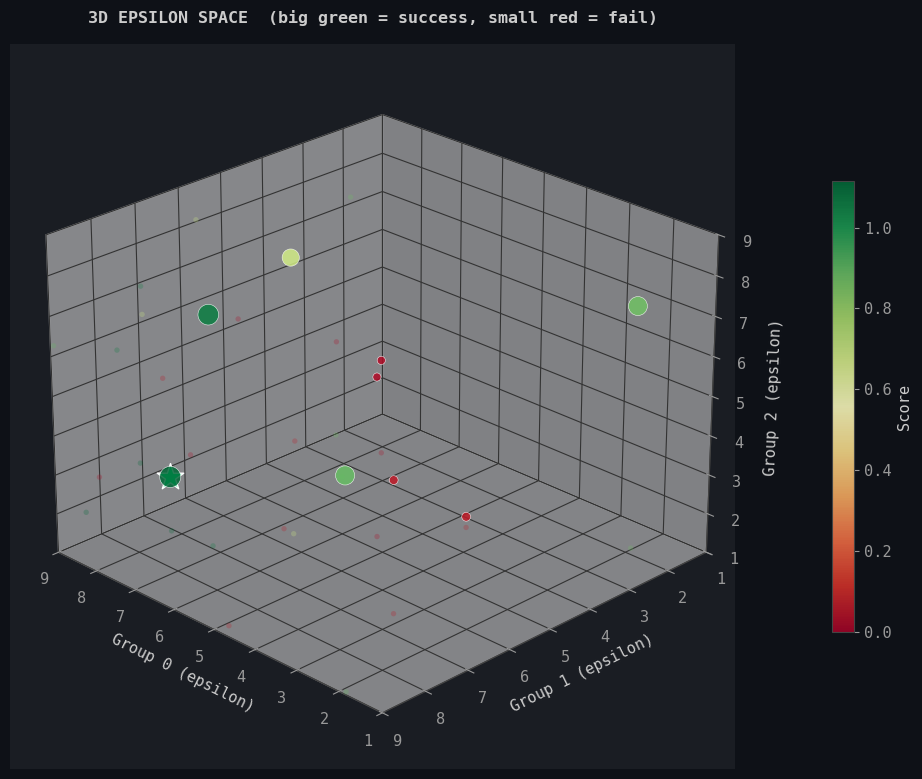

In [143]:
# 3D SCATTER: all three epsilons at once
# Size = score, color = score. One dot per run.

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.set_facecolor("#1a1d23")

scores_norm = scores / score_max  # normalize for size/alpha
sizes = 30 + 200 * scores_norm

sc = ax.scatter(eps[:, 0], eps[:, 1], eps[:, 2],
                c=scores, cmap="RdYlGn", s=sizes, vmin=0, vmax=score_max,
                edgecolors="white", linewidths=0.4, alpha=0.85, depthshade=False)

best = np.argmax(scores)
ax.scatter(eps[best, 0], eps[best, 1], eps[best, 2],
           marker="*", s=400, color="#00ff88", edgecolors="white",
           linewidths=1, zorder=6, depthshade=False)

ax.scatter(eps[:, 0], eps[:, 1], np.full(len(eps), 1),
           c=scores, cmap="RdYlGn", s=15, alpha=0.25, vmin=0, vmax=score_max,
           edgecolors="none", depthshade=False)
ax.scatter(eps[:, 0], np.full(len(eps), 9), eps[:, 2],
           c=scores, cmap="RdYlGn", s=15, alpha=0.25, vmin=0, vmax=score_max,
           edgecolors="none", depthshade=False)
ax.scatter(np.full(len(eps), 9), eps[:, 1], eps[:, 2],
           c=scores, cmap="RdYlGn", s=15, alpha=0.25, vmin=0, vmax=score_max,
           edgecolors="none", depthshade=False)

ax.set_xlabel("Group 0 (epsilon)")
ax.set_ylabel("Group 1 (epsilon)")
ax.set_zlabel("Group 2 (epsilon)")
ax.set_xlim(1, 9)
ax.set_ylim(1, 9)
ax.set_zlim(1, 9)
ax.set_title("3D EPSILON SPACE  (big green = success, small red = fail)",
             fontweight="bold", fontsize=12, pad=15)
ax.view_init(elev=25, azim=135)

fig.colorbar(sc, ax=ax, label="Score", shrink=0.6, pad=0.1)
plt.tight_layout()
plt.show()

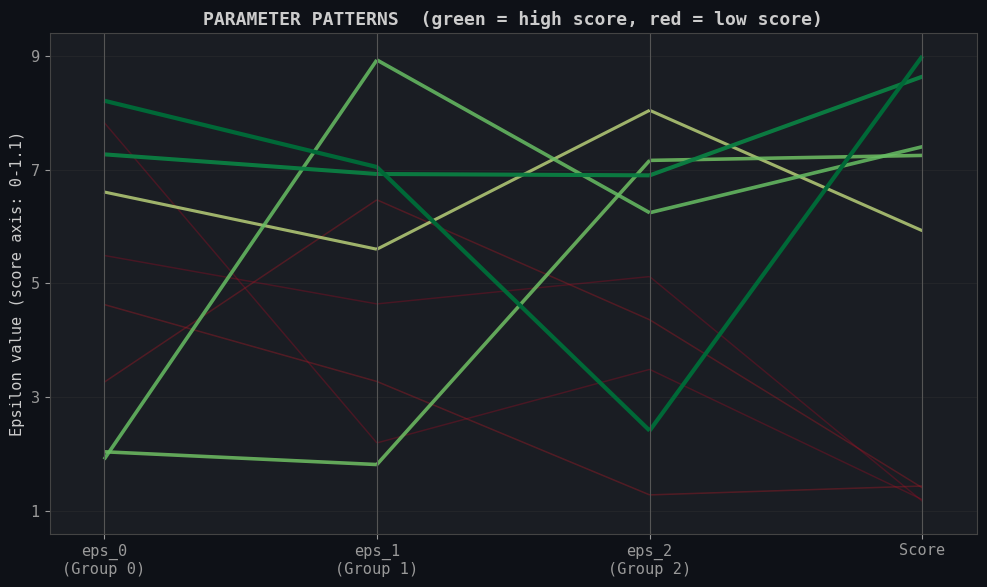

In [144]:
# PARALLEL COORDINATES
# Each line = one run, passing through eps_0, eps_1, eps_2
# Color = score. Shows which PATTERNS of epsilons work.

fig, ax = plt.subplots(figsize=(10, 6))

x_coords = [0, 1, 2, 3]  # eps_0, eps_1, eps_2, score
x_labels = ["eps_0\n(Group 0)", "eps_1\n(Group 1)", "eps_2\n(Group 2)", "Score"]

# Normalize each axis to [0, 1] for display
data = np.column_stack([eps, scores])
mins = np.array([1, 1, 1, 0], dtype=float)
maxs = np.array([9, 9, 9, score_max], dtype=float)
normed = (data - mins) / (maxs - mins)

scores_norm = scores / score_max
order = np.argsort(scores)

for idx in order:
    y = normed[idx]
    points = np.column_stack([x_coords, y]).reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    color = plt.cm.RdYlGn(scores_norm[idx])
    alpha = np.clip(0.3 + 0.7 * scores_norm[idx], 0, 1)
    lw = 1.0 + 2.0 * scores_norm[idx]

    lc = LineCollection(segments, colors=[color], alpha=alpha, linewidths=lw)
    ax.add_collection(lc)

for x in x_coords:
    ax.axvline(x, color="#555", lw=0.8)

ax.set_xticks(x_coords)
ax.set_xticklabels(x_labels)
ax.set_xlim(-0.2, 3.2)
ax.set_ylim(-0.05, 1.05)

yticks = np.linspace(0, 1, 5)
ax.set_yticks(yticks)
ax.set_yticklabels([f"{v:.0f}" for v in np.linspace(1, 9, 5)])
ax.set_ylabel("Epsilon value (score axis: 0-{:.1f})".format(score_max))

ax.set_title("PARAMETER PATTERNS  (green = high score, red = low score)",
             fontweight="bold", fontsize=13)
ax.grid(True, axis="y")
plt.tight_layout()
plt.show()

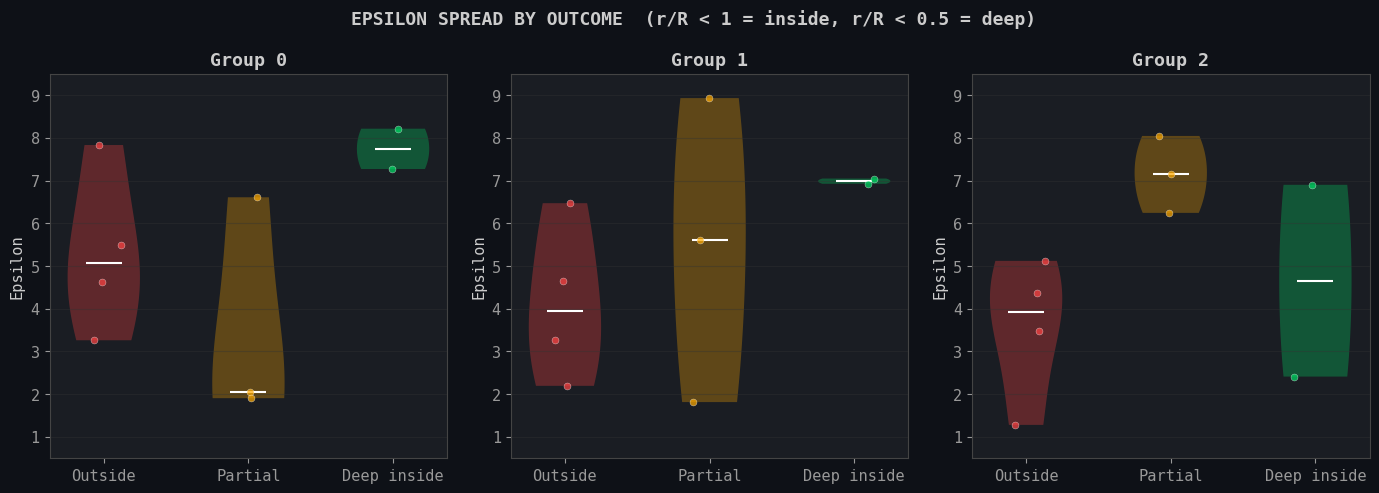

In [145]:
# 4. EPSILON SPREADS: violin + strip for inside vs outside
# Shows the DISTRIBUTION of what works vs what doesn't

inside = rR < 1.0      # MP center inside membrane
deep = rR < 0.5        # clearly deep inside

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
group_names = ["Group 0", "Group 1", "Group 2"]

for i, ax in enumerate(axes):
    categories = []
    data_cat = []

    if (~inside).sum() > 0:
        categories.append("Outside")
        data_cat.append(eps[~inside, i])
    if (inside & ~deep).sum() > 0:
        categories.append("Partial")
        data_cat.append(eps[inside & ~deep, i])
    if deep.sum() > 0:
        categories.append("Deep inside")
        data_cat.append(eps[deep, i])

    colors_cat = {"Outside": "#ff4444", "Partial": "#ffaa00", "Deep inside": "#00dd66"}
    positions = list(range(len(categories)))

    if len(data_cat) > 0:
        parts = ax.violinplot(data_cat, positions=positions, showmedians=True,
                              showextrema=False)
        for pc, cat in zip(parts["bodies"], categories):
            pc.set_facecolor(colors_cat[cat])
            pc.set_alpha(0.3)
        parts["cmedians"].set_color("white")

        # Strip plot (jittered dots)
        for pos, cat, d in zip(positions, categories, data_cat):
            jitter = np.random.normal(0, 0.06, len(d))
            ax.scatter(pos + jitter, d, c=colors_cat[cat], s=25,
                      alpha=0.7, edgecolors="white", linewidths=0.3, zorder=5)

    ax.set_xticks(positions)
    ax.set_xticklabels(categories)
    ax.set_ylabel("Epsilon")
    ax.set_ylim(0.5, 9.5)
    ax.set_title(group_names[i], fontweight="bold")
    ax.grid(True, axis="y")

fig.suptitle("EPSILON SPREAD BY OUTCOME  (r/R < 1 = inside, r/R < 0.5 = deep)",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

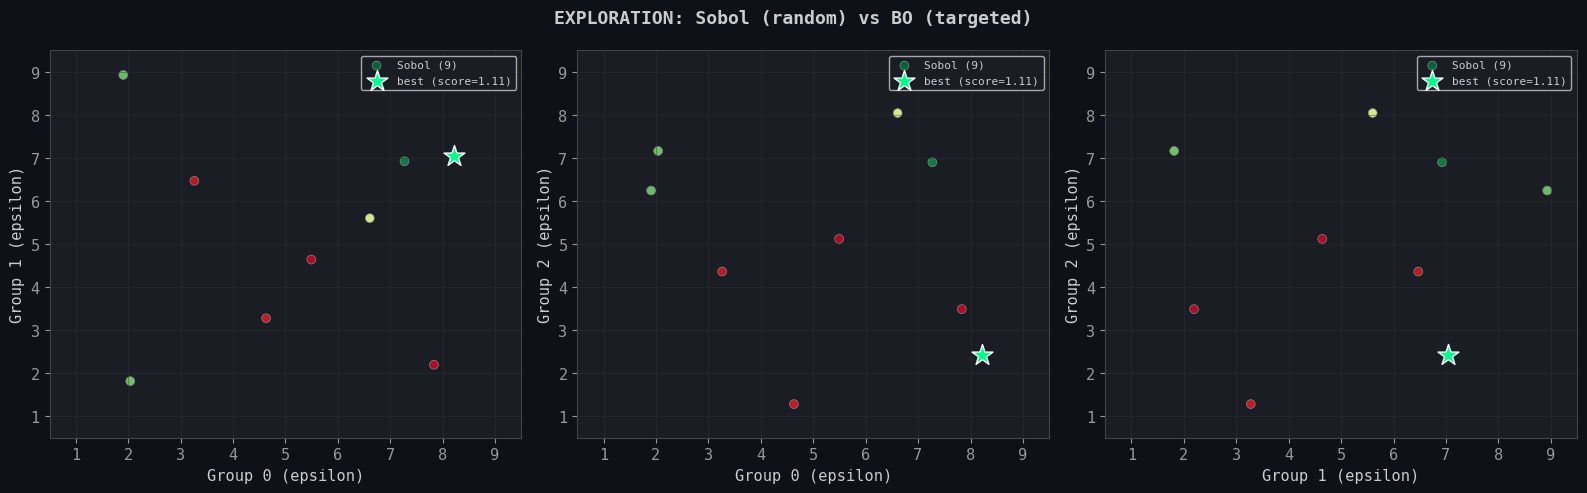

In [146]:
# 5. SAMPLING STRATEGY: where is BO choosing to explore?

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pair_idx = [(0, 1), (0, 2), (1, 2)]
pair_names = [("Group 0", "Group 1"), ("Group 0", "Group 2"), ("Group 1", "Group 2")]

sobol_mask = eval_ids < n_initial
bo_mask = eval_ids >= n_initial

for ax, (i, j), (ni, nj) in zip(axes, pair_idx, pair_names):
    if sobol_mask.sum() > 0:
        ax.scatter(eps[sobol_mask, i], eps[sobol_mask, j],
                  c=scores[sobol_mask], cmap="RdYlGn", vmin=0, vmax=score_max,
                  s=40, marker="o", edgecolors="#888", linewidths=0.5,
                  label=f"Sobol ({sobol_mask.sum()})")

    if bo_mask.sum() > 1:
        bo_eps_i = eps[bo_mask, i]
        bo_eps_j = eps[bo_mask, j]
        ax.plot(bo_eps_i, bo_eps_j, color="#666", lw=0.8, alpha=0.5, zorder=3)
        ax.scatter(bo_eps_i, bo_eps_j,
                  c=scores[bo_mask], cmap="RdYlGn", vmin=0, vmax=score_max,
                  s=70, marker="D", edgecolors="white", linewidths=0.8,
                  label=f"BO ({bo_mask.sum()})", zorder=4)
    elif bo_mask.sum() == 1:
        ax.scatter(eps[bo_mask, i], eps[bo_mask, j],
                  c=scores[bo_mask], cmap="RdYlGn", vmin=0, vmax=score_max,
                  s=70, marker="D", edgecolors="white", linewidths=0.8,
                  label=f"BO ({bo_mask.sum()})", zorder=4)

    best = np.argmax(scores)
    ax.scatter(eps[best, i], eps[best, j], marker="*", s=250,
              color="#00ff88", edgecolors="white", linewidths=1, zorder=6,
              label=f"best (score={scores[best]:.2f})")

    ax.set_xlabel(f"{ni} (epsilon)")
    ax.set_ylabel(f"{nj} (epsilon)")
    ax.set_xlim(0.5, 9.5)
    ax.set_ylim(0.5, 9.5)
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True)

fig.suptitle("EXPLORATION: Sobol (random) vs BO (targeted)",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

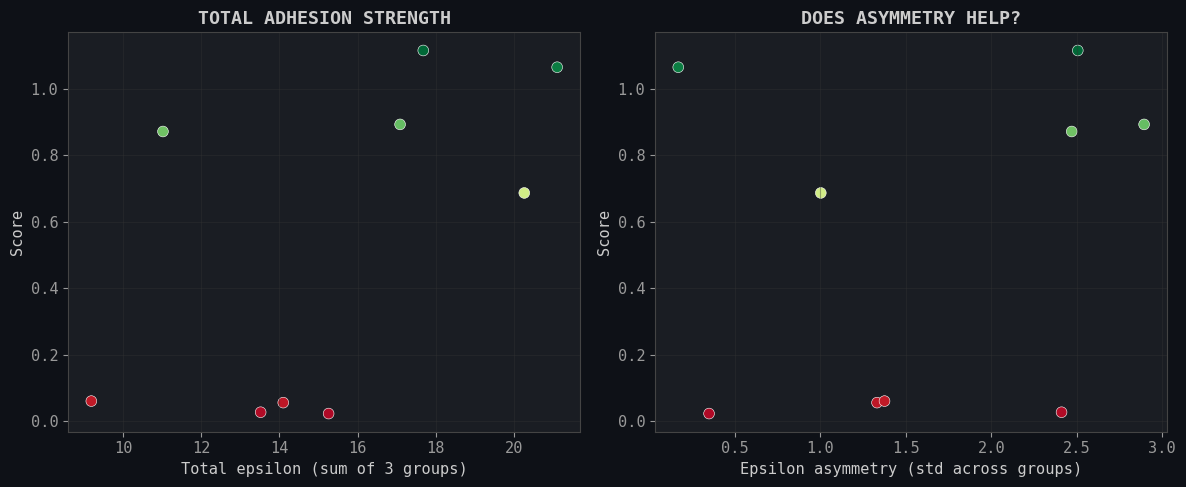

In [147]:
# 6. TOTAL EPSILON vs OUTCOME

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

eps_total = eps.sum(axis=1)
eps_std = eps.std(axis=1)

sc = ax1.scatter(eps_total, scores, c=scores, cmap="RdYlGn",
                 s=60, edgecolors="white", linewidths=0.4, vmin=0, vmax=score_max)
ax1.set_xlabel("Total epsilon (sum of 3 groups)")
ax1.set_ylabel("Score")
ax1.set_title("TOTAL ADHESION STRENGTH", fontweight="bold")
ax1.grid(True)

ax2.scatter(eps_std, scores, c=scores, cmap="RdYlGn",
            s=60, edgecolors="white", linewidths=0.4, vmin=0, vmax=score_max)
ax2.set_xlabel("Epsilon asymmetry (std across groups)")
ax2.set_ylabel("Score")
ax2.set_title("DOES ASYMMETRY HELP?", fontweight="bold")
ax2.grid(True)

plt.tight_layout()
plt.show()

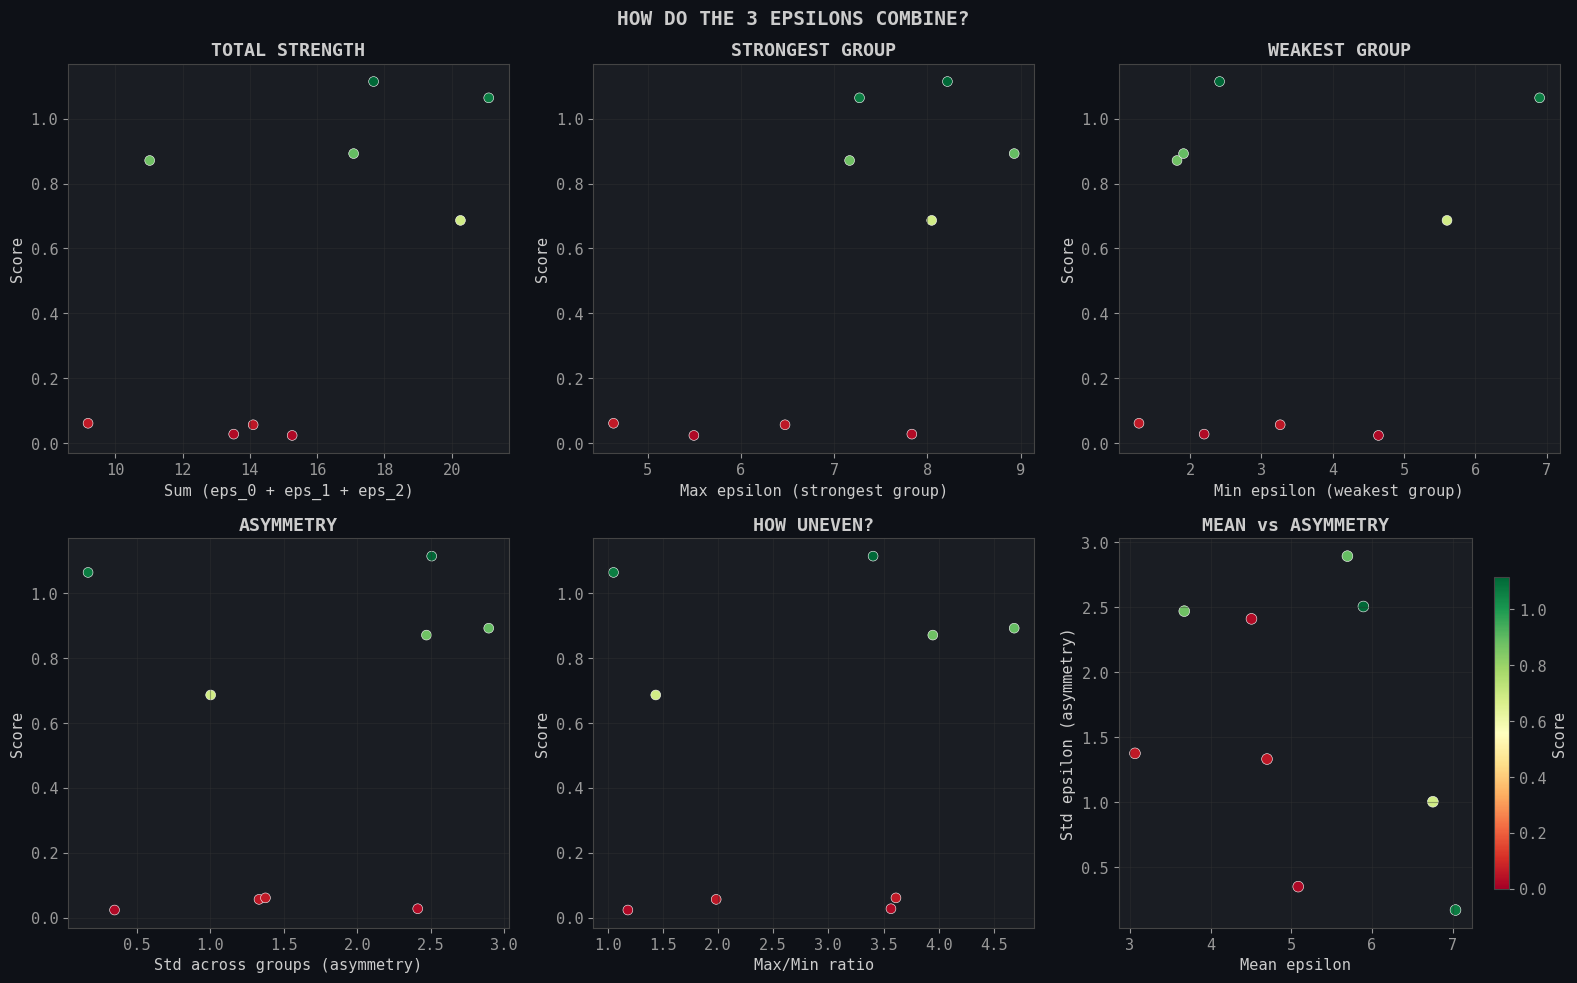

In [148]:
# COMBINED STATISTICS: how do the 3 epsilons interact?

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

eps_sum = eps.sum(axis=1)
eps_mean = eps.mean(axis=1)
eps_std = eps.std(axis=1)
eps_max = eps.max(axis=1)
eps_min = eps.min(axis=1)
eps_range = eps_max - eps_min

ax = axes[0, 0]
ax.scatter(eps_sum, scores, c=scores, cmap="RdYlGn", s=50,
           edgecolors="white", linewidths=0.4, vmin=0, vmax=score_max)
ax.set_xlabel("Sum (eps_0 + eps_1 + eps_2)")
ax.set_ylabel("Score")
ax.set_title("TOTAL STRENGTH", fontweight="bold")
ax.grid(True)

ax = axes[0, 1]
ax.scatter(eps_max, scores, c=scores, cmap="RdYlGn", s=50,
           edgecolors="white", linewidths=0.4, vmin=0, vmax=score_max)
ax.set_xlabel("Max epsilon (strongest group)")
ax.set_ylabel("Score")
ax.set_title("STRONGEST GROUP", fontweight="bold")
ax.grid(True)

ax = axes[0, 2]
ax.scatter(eps_min, scores, c=scores, cmap="RdYlGn", s=50,
           edgecolors="white", linewidths=0.4, vmin=0, vmax=score_max)
ax.set_xlabel("Min epsilon (weakest group)")
ax.set_ylabel("Score")
ax.set_title("WEAKEST GROUP", fontweight="bold")
ax.grid(True)

ax = axes[1, 0]
ax.scatter(eps_std, scores, c=scores, cmap="RdYlGn", s=50,
           edgecolors="white", linewidths=0.4, vmin=0, vmax=score_max)
ax.set_xlabel("Std across groups (asymmetry)")
ax.set_ylabel("Score")
ax.set_title("ASYMMETRY", fontweight="bold")
ax.grid(True)

ax = axes[1, 1]
ratio = eps_max / np.clip(eps_min, 0.1, None)
ax.scatter(ratio, scores, c=scores, cmap="RdYlGn", s=50,
           edgecolors="white", linewidths=0.4, vmin=0, vmax=score_max)
ax.set_xlabel("Max/Min ratio")
ax.set_ylabel("Score")
ax.set_title("HOW UNEVEN?", fontweight="bold")
ax.grid(True)

ax = axes[1, 2]
sc = ax.scatter(eps_mean, eps_std, c=scores, cmap="RdYlGn", s=60,
                edgecolors="white", linewidths=0.4, vmin=0, vmax=score_max)
ax.set_xlabel("Mean epsilon")
ax.set_ylabel("Std epsilon (asymmetry)")
ax.set_title("MEAN vs ASYMMETRY", fontweight="bold")
ax.grid(True)
fig.colorbar(sc, ax=ax, label="Score", shrink=0.8)

fig.suptitle("HOW DO THE 3 EPSILONS COMBINE?", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

In [149]:
# WRAPPING DATA: use stored values from bo_results.json
# New runs have n_contacts, coverage (solid angle), depth stored directly.
# For runs with dump files but no stored data, recompute using solid_angle_coverage.

import sys, os
sys.path.insert(0, ".")
from bo_phase1 import parse_last_frame, solid_angle_coverage

wrapping_data = []

for i, r in enumerate(ok):
    eid = r["eval_id"]

    # Prefer stored data (new format with solid angle coverage)
    if "coverage" in r and r["coverage"] is not None:
        wrapping_data.append({
            "eval_id": eid, "n_contacts": r.get("n_contacts", 0),
            "coverage": r["coverage"], "has_data": True,
        })
        print(f"eval {eid:>2d}: n={r.get('n_contacts',0):>5d}  "
              f"coverage={r['coverage']:.3f}  depth={r.get('depth',0):.3f}  "
              f"score={r['objective']:.4f}  [from JSON]")
        continue

    # Fallback: recompute from dump using solid angle coverage
    dump_path = f"bo_runs/eval_{eid:04d}/position.lammpstrj"
    if os.path.exists(dump_path):
        try:
            atoms = parse_last_frame(dump_path)
            mp_pos = np.array([[x, y, z] for aid, (atype, x, y, z) in atoms.items() if 2 <= atype <= 61])
            mem_pos = np.array([[x, y, z] for aid, (atype, x, y, z) in atoms.items() if atype == 1])

            cov, nc = solid_angle_coverage(mp_pos, mem_pos)

            wrapping_data.append({
                "eval_id": eid, "n_contacts": nc, "coverage": cov,
                "has_data": True,
            })
            print(f"eval {eid:>2d}: n={nc:>5d}  coverage={cov:.3f}  [recomputed from dump]")
        except Exception as e:
            wrapping_data.append({"eval_id": eid, "has_data": False})
            print(f"eval {eid:>2d}: parse error: {e}")
    else:
        wrapping_data.append({"eval_id": eid, "has_data": False})
        print(f"eval {eid:>2d}: no data")

w_available = sum(1 for w in wrapping_data if w["has_data"])
print(f"\n{w_available}/{len(wrapping_data)} runs have coverage data")

eval  0: n=  344  coverage=0.875  depth=0.594  score=1.1146  [from JSON]
eval  1: n=  401  coverage=0.923  depth=0.453  score=0.8711  [from JSON]
eval  2: n=  355  coverage=0.839  depth=0.031  score=0.0564  [from JSON]
eval  3: n=  368  coverage=0.841  depth=0.026  score=0.0236  [from JSON]
eval  4: n=  341  coverage=0.811  depth=0.379  score=0.6865  [from JSON]
eval  5: n=  393  coverage=0.890  depth=0.065  score=0.0610  [from JSON]
eval  6: n=  375  coverage=0.924  depth=0.464  score=0.8925  [from JSON]
eval  7: n=  284  coverage=0.701  depth=0.016  score=0.0276  [from JSON]
eval  8: n=  388  coverage=0.927  depth=0.552  score=1.0643  [from JSON]

9/9 runs have coverage data


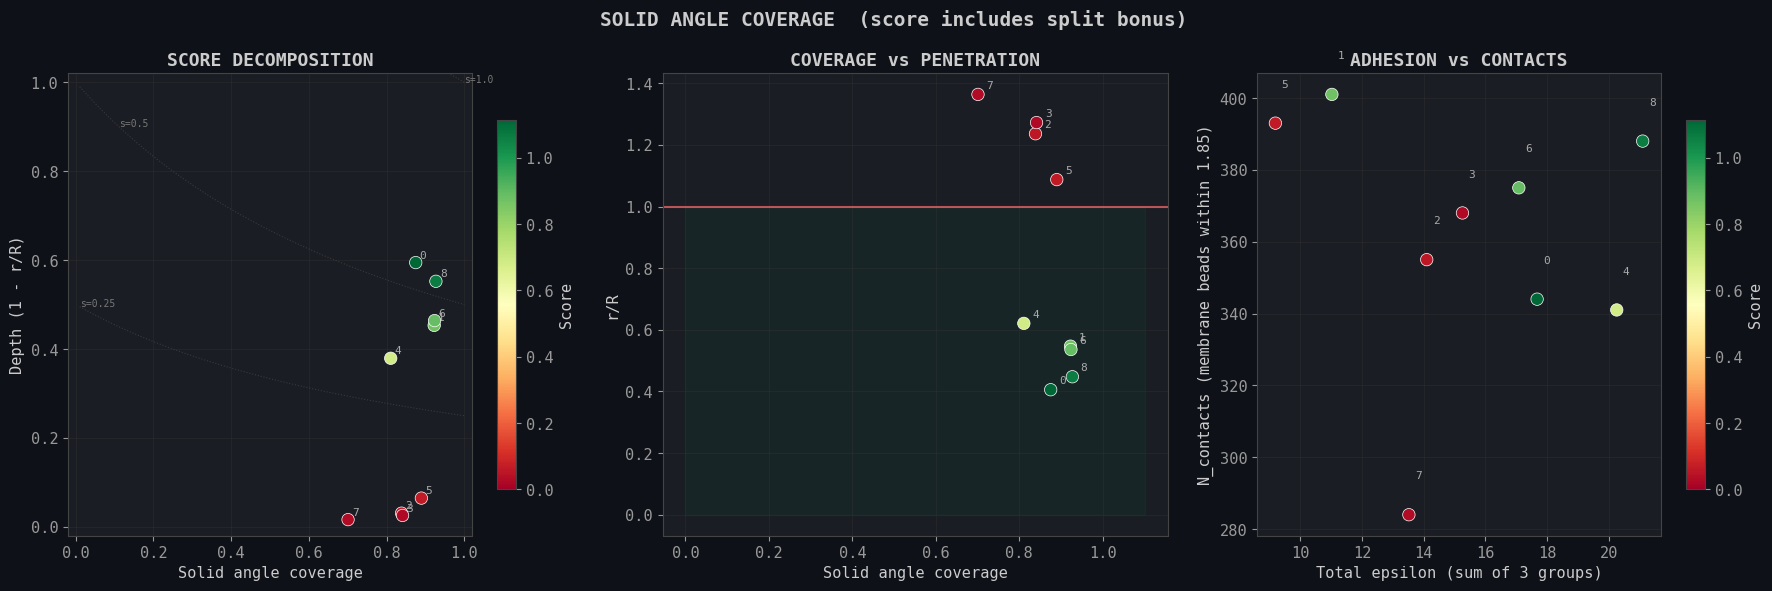

In [150]:
# WRAPPING ANALYSIS (solid angle coverage)

w_mask = np.array([w["has_data"] for w in wrapping_data])

if w_mask.sum() > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    w_idx = np.where(w_mask)[0]
    w_cov = coverage[w_idx]
    w_depth = depth[w_idx]
    w_rR = rR[w_idx]
    w_scores = scores[w_idx]
    w_eps = eps[w_idx]
    w_eids = eval_ids[w_idx]
    w_nc = n_contacts[w_idx]

    ax = axes[0]
    sc = ax.scatter(w_cov, w_depth, c=w_scores, cmap="RdYlGn", s=80,
                    edgecolors="white", linewidths=0.5, vmin=0, vmax=score_max, zorder=5)
    for k, eid in enumerate(w_eids):
        ax.text(w_cov[k] + 0.01, w_depth[k] + 0.01, str(eid),
                fontsize=8, color="#aaa")

    cc = np.linspace(0.01, 1, 100)
    for s_level in [0.25, 0.5, 1.0]:
        dd = s_level / (0.5 + 0.5 * cc)
        ax.plot(cc, dd, color="#555", ls=":", lw=0.8, alpha=0.5)
        valid = dd <= 1.05
        if valid.any():
            idx_label = np.argmin(np.abs(dd - 0.9))
            ax.text(cc[idx_label], dd[idx_label], f"s={s_level}",
                    fontsize=7, color="#777")

    ax.set_xlabel("Solid angle coverage")
    ax.set_ylabel("Depth (1 - r/R)")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_title("SCORE DECOMPOSITION", fontweight="bold", fontsize=13)
    ax.grid(True)
    fig.colorbar(sc, ax=ax, label="Score", shrink=0.8)

    ax = axes[1]
    sc2 = ax.scatter(w_cov, w_rR, c=w_scores, cmap="RdYlGn", s=80,
                     edgecolors="white", linewidths=0.5, vmin=0, vmax=score_max, zorder=5)
    for k, eid in enumerate(w_eids):
        ax.text(w_cov[k] + 0.02, w_rR[k] + 0.02, str(eid),
                fontsize=8, color="#aaa")
    ax.axhline(1.0, color="#ff6b6b", ls="-", lw=1.5, alpha=0.7)
    ax.fill_betweenx([0, 1], 0, 1.1, alpha=0.04, color="#00ff88")
    ax.set_xlabel("Solid angle coverage")
    ax.set_ylabel("r/R")
    ax.set_title("COVERAGE vs PENETRATION", fontweight="bold", fontsize=13)
    ax.grid(True)

    ax = axes[2]
    eps_total = w_eps.sum(axis=1)
    sc3 = ax.scatter(eps_total, w_nc, c=w_scores, cmap="RdYlGn", s=80,
                     edgecolors="white", linewidths=0.5, vmin=0, vmax=score_max, zorder=5)
    for k, eid in enumerate(w_eids):
        ax.text(eps_total[k] + 0.2, w_nc[k] + 10, str(eid),
                fontsize=8, color="#aaa")
    ax.set_xlabel("Total epsilon (sum of 3 groups)")
    ax.set_ylabel("N_contacts (membrane beads within 1.85)")
    ax.set_title("ADHESION vs CONTACTS", fontweight="bold", fontsize=13)
    ax.grid(True)
    fig.colorbar(sc3, ax=ax, label="Score", shrink=0.8)

    fig.suptitle("SOLID ANGLE COVERAGE  (score includes split bonus)",
                 fontweight="bold", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No coverage data available yet")

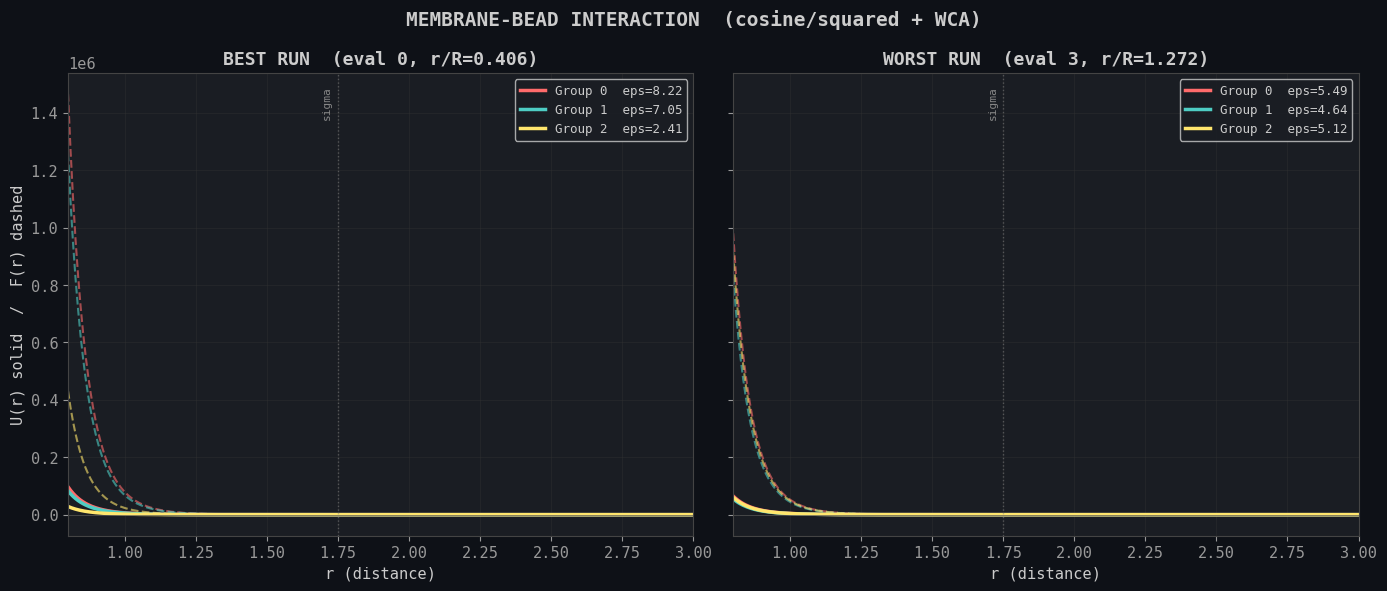

In [151]:
# COSINE/SQUARED + WCA POTENTIAL: best run vs worst run
# Shows the actual membrane-bead interaction potential for each group
# Left: best run (deepest penetration), Right: worst run (stayed outside)

def cosine_squared_wca(r, epsilon, sigma=1.75, rc=1.85):
    """Cosine/squared pair potential with WCA repulsive core (LAMMPS style)."""
    U = np.full_like(r, np.nan)
    F = np.full_like(r, np.nan)
    sigma_wca = sigma / 2**(1/6)

    # WCA region: r < sigma (standard LJ, minimum at sigma)
    wca = r < sigma
    sr6 = (sigma_wca / r[wca])**6
    sr12 = sr6**2
    U[wca] = 4 * epsilon * (sr12 - sr6)
    F[wca] = 24 * epsilon * (2 * sr12 - sr6) / r[wca]

    # Cosine/squared region: sigma <= r <= rc
    cos_region = (r >= sigma) & (r <= rc)
    arg = np.pi * (r[cos_region] - sigma) / (2 * (rc - sigma))
    U[cos_region] = -epsilon * np.cos(arg)**2
    F[cos_region] = -epsilon * np.pi / (rc - sigma) * np.cos(arg) * np.sin(arg)

    # Beyond cutoff
    beyond = r > rc
    U[beyond] = 0.0
    F[beyond] = 0.0

    return U, F

r = np.linspace(0.8, 3.0, 500)

best_idx = np.argmax(scores)
worst_idx = np.argmin(scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
group_names = ["Group 0", "Group 1", "Group 2"]

for ax, idx, label in zip(axes, [best_idx, worst_idx],
                           ["BEST RUN", "WORST RUN"]):
    e = eps[idx]
    rr = rR[idx]
    eid = eval_ids[idx]

    for g in range(3):
        U, F = cosine_squared_wca(r, e[g])
        ax.plot(r, U, color=group_colors[g], lw=2.5,
                label=f"{group_names[g]}  eps={e[g]:.2f}")
        ax.plot(r, F, color=group_colors[g], lw=1.5, ls="--", alpha=0.6)

    ax.axhline(0, color="#555", lw=0.5)
    ax.set_xlabel("r (distance)")
    ax.set_title(f"{label}  (eval {eid}, r/R={rr:.3f})",
                 fontweight="bold", fontsize=13)
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(True)
    ax.set_xlim(0.8, 3.0)

    # WCA/attractive boundary
    ax.axvline(1.75, color="#888", ls=":", lw=1, alpha=0.5)
    ax.text(1.73, ax.get_ylim()[1] * 0.9, "sigma", fontsize=8,
            color="#888", ha="right", rotation=90)

axes[0].set_ylabel("U(r) solid  /  F(r) dashed")

fig.suptitle("MEMBRANE-BEAD INTERACTION  (cosine/squared + WCA)",
             fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

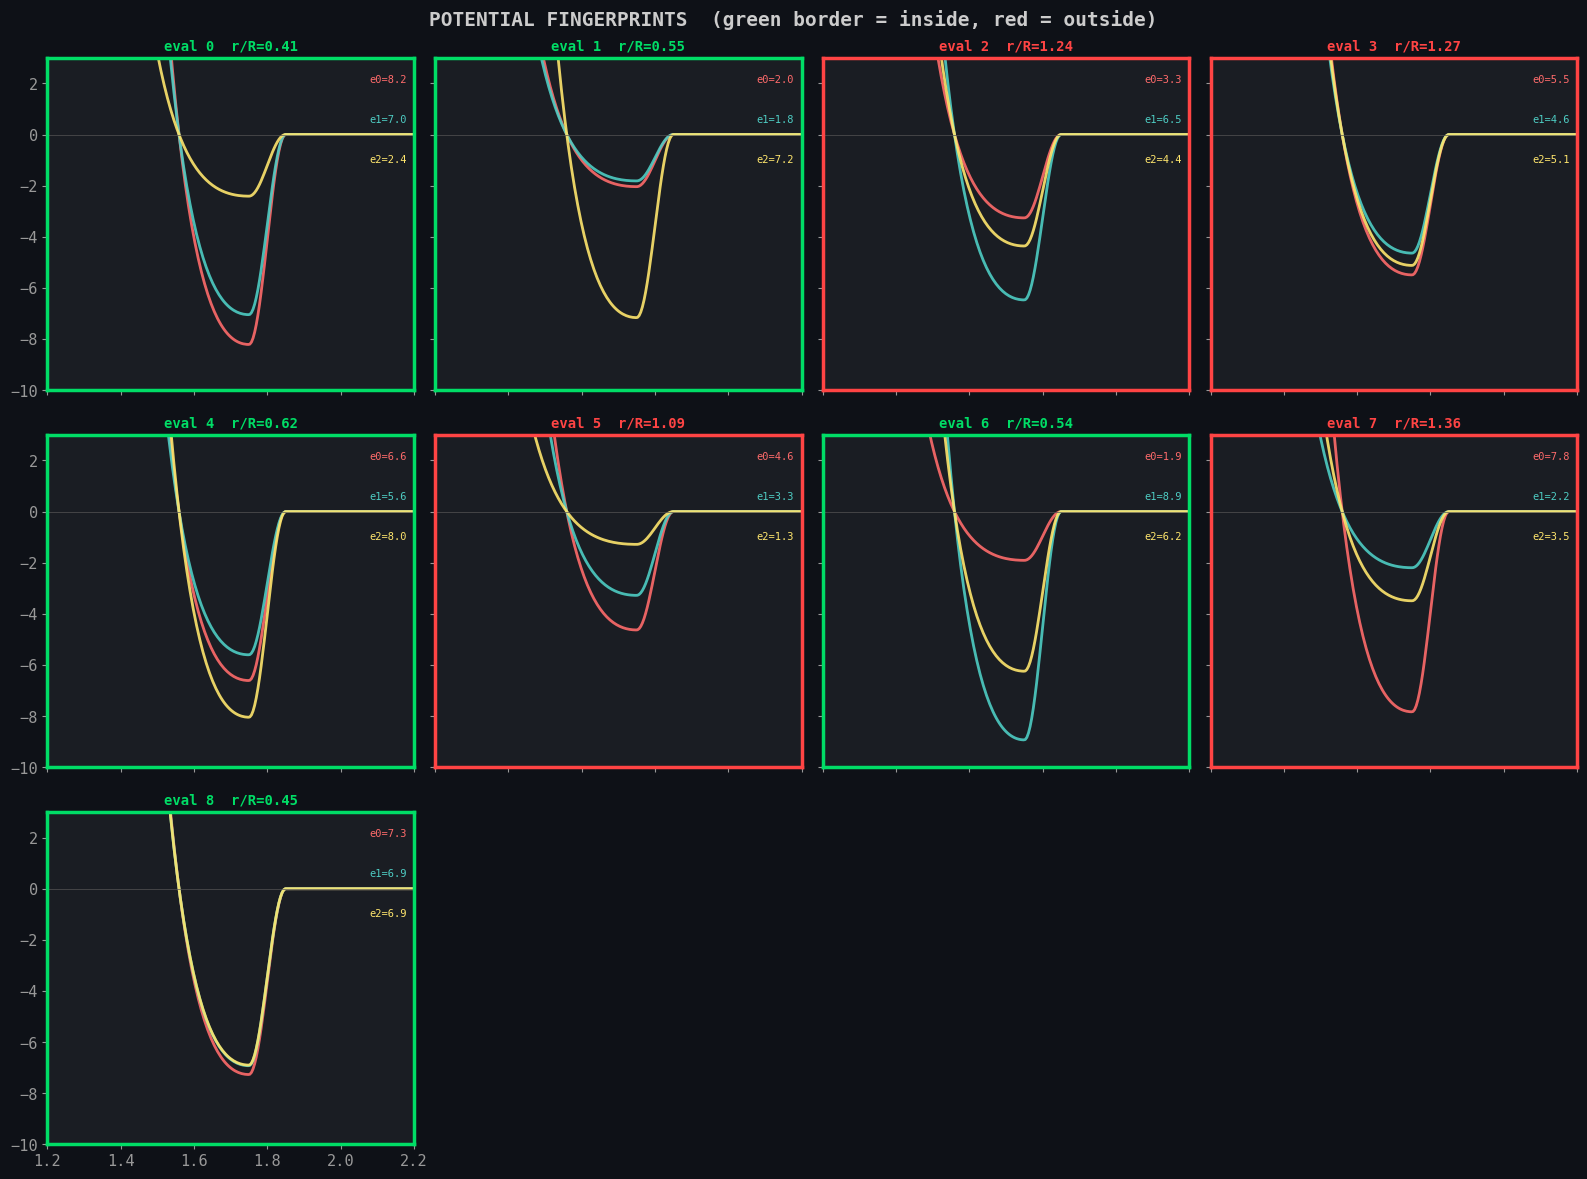

In [152]:
# POTENTIAL FINGERPRINTS: small multiples grid
# Each subplot = one run's 3 interaction potentials
# Border color: green = inside, red = outside

n_runs = len(ok)
ncols = 4
nrows = int(np.ceil(n_runs / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows),
                         sharex=True, sharey=True)
axes_flat = axes.flatten()

sorted_idx = np.argsort(eval_ids)

for i, idx in enumerate(sorted_idx):
    ax = axes_flat[i]
    e = eps[idx]
    rr = rR[idx]
    eid = eval_ids[idx]
    s = scores[idx]
    is_inside = rr < 1.0

    for g in range(3):
        U, F = cosine_squared_wca(r, e[g])
        ax.plot(r, U, color=group_colors[g], lw=2, alpha=0.9)

    ax.axhline(0, color="#555", lw=0.5)
    ax.set_xlim(1.2, 2.2)
    ax.set_ylim(-10, 3)

    # Border color by outcome
    border_color = "#00dd66" if is_inside else "#ff4444"
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(2.5)

    ax.set_title(f"eval {eid}  r/R={rr:.2f}",
                 fontsize=10, fontweight="bold",
                 color=border_color)

    # Small epsilon labels
    for g in range(3):
        ax.text(0.98, 0.95 - g * 0.12, f"e{g}={e[g]:.1f}",
                transform=ax.transAxes, fontsize=7.5, color=group_colors[g],
                ha="right", va="top")

# Hide unused subplots
for i in range(n_runs, len(axes_flat)):
    axes_flat[i].set_visible(False)

fig.suptitle("POTENTIAL FINGERPRINTS  (green border = inside, red = outside)",
             fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

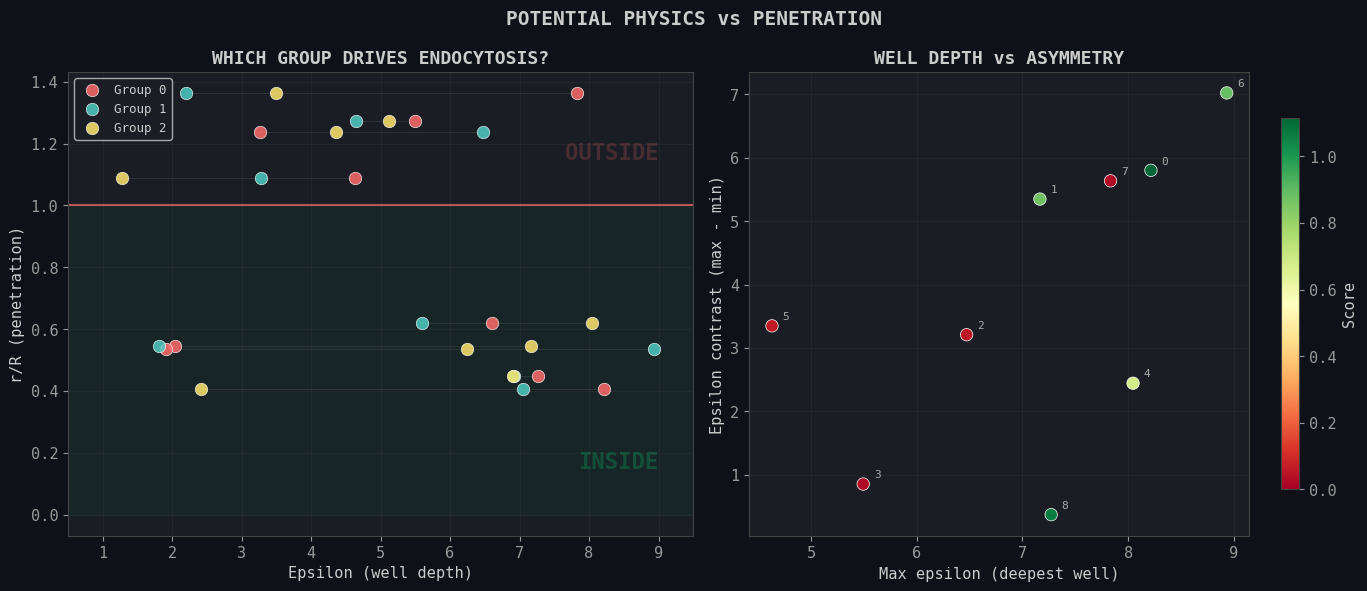

In [153]:
# WELL DEPTH vs PENETRATION: which group's epsilon matters most?

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
group_names = ["Group 0", "Group 1", "Group 2"]

for g in range(3):
    ax1.scatter(eps[:, g], rR, c=group_colors[g], s=80,
                edgecolors="white", linewidths=0.5, label=group_names[g],
                alpha=0.85, zorder=5)

for k in range(len(eps)):
    for g1 in range(3):
        for g2 in range(g1 + 1, 3):
            ax1.plot([eps[k, g1], eps[k, g2]], [rR[k], rR[k]],
                     color="#555", lw=0.5, alpha=0.3)

ax1.axhline(1.0, color="#ff6b6b", ls="-", lw=1.5, alpha=0.7)
ax1.fill_between([0, 10], 0, 1, alpha=0.04, color="#00ff88")
ax1.text(9, 0.15, "INSIDE", fontsize=16, color="#00ff88", alpha=0.2,
         fontweight="bold", ha="right")
ax1.text(9, 1.15, "OUTSIDE", fontsize=16, color="#ff6b6b", alpha=0.2,
         fontweight="bold", ha="right")
ax1.set_xlabel("Epsilon (well depth)")
ax1.set_ylabel("r/R (penetration)")
ax1.set_title("WHICH GROUP DRIVES ENDOCYTOSIS?", fontweight="bold", fontsize=13)
ax1.legend(fontsize=9, loc="upper left")
ax1.set_xlim(0.5, 9.5)
ax1.grid(True)

eps_max_val = eps.max(axis=1)
eps_contrast = eps.max(axis=1) - eps.min(axis=1)

sc = ax2.scatter(eps_max_val, eps_contrast, c=scores, cmap="RdYlGn",
                 s=80, edgecolors="white", linewidths=0.5, vmin=0, vmax=score_max,
                 zorder=5)

for k in range(len(eps)):
    ax2.text(eps_max_val[k] + 0.1, eps_contrast[k] + 0.1,
             str(eval_ids[k]), fontsize=8, color="#aaa")

ax2.set_xlabel("Max epsilon (deepest well)")
ax2.set_ylabel("Epsilon contrast (max - min)")
ax2.set_title("WELL DEPTH vs ASYMMETRY", fontweight="bold", fontsize=13)
ax2.grid(True)
fig.colorbar(sc, ax=ax2, label="Score", shrink=0.8)

fig.suptitle("POTENTIAL PHYSICS vs PENETRATION",
             fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

In [154]:
# MEMBRANE CLUSTERING: does the membrane split into pocket + vesicle?
# DBSCAN on membrane bead positions detects neck pinch-off.
# 2 clusters = pocket formed (real endocytosis), 1 = still connected (wall hug)

import sys, os
sys.path.insert(0, ".")
from bo_phase1 import parse_last_frame
from sklearn.cluster import DBSCAN

DBSCAN_EPS = 1.5

cluster_data = []
for i, r in enumerate(ok):
    eid = r["eval_id"]
    dump = f"bo_runs/eval_{eid:04d}/position.lammpstrj"
    if not os.path.exists(dump):
        cluster_data.append({"eval_id": eid, "n_clusters": None})
        continue

    atoms = parse_last_frame(dump)
    mem_pos = np.array([[x, y, z] for aid, (atype, x, y, z) in atoms.items() if atype == 1])
    mp_pos = np.array([[x, y, z] for aid, (atype, x, y, z) in atoms.items() if 2 <= atype <= 61])

    labels = DBSCAN(eps=DBSCAN_EPS, min_samples=5).fit_predict(mem_pos)
    n_clusters = len(set(labels) - {-1})
    sizes = sorted([np.sum(labels == l) for l in set(labels) - {-1}], reverse=True)
    noise = int((labels == -1).sum())

    cluster_data.append({
        "eval_id": eid, "n_clusters": n_clusters,
        "cluster_sizes": sizes, "noise": noise,
        "labels": labels, "mem_pos": mem_pos, "mp_pos": mp_pos,
    })
    rr = r["radial_ratio"]
    split = "SPLIT" if n_clusters >= 2 else "INTACT"
    print(f"eval {eid:>2d} (r/R={rr:.2f}): {n_clusters} clusters  "
          f"sizes={sizes[:4]}  noise={noise}  -> {split}")

n_split = sum(1 for c in cluster_data if c["n_clusters"] is not None and c["n_clusters"] >= 2)
print(f"\n{n_split}/{len(cluster_data)} runs show membrane split (DBSCAN eps={DBSCAN_EPS})")

eval  0 (r/R=0.41): 2 clusters  sizes=[4127, 344]  noise=29  -> SPLIT
eval  1 (r/R=0.55): 2 clusters  sizes=[4064, 401]  noise=35  -> SPLIT
eval  2 (r/R=1.24): 2 clusters  sizes=[4099, 350]  noise=51  -> SPLIT
eval  3 (r/R=1.27): 1 clusters  sizes=[4483]  noise=17  -> INTACT
eval  4 (r/R=0.62): 2 clusters  sizes=[4106, 338]  noise=56  -> SPLIT
eval  5 (r/R=1.09): 1 clusters  sizes=[4467]  noise=33  -> INTACT
eval  6 (r/R=0.54): 2 clusters  sizes=[4039, 376]  noise=85  -> SPLIT
eval  7 (r/R=1.36): 2 clusters  sizes=[4204, 279]  noise=17  -> SPLIT
eval  8 (r/R=0.45): 2 clusters  sizes=[4069, 390]  noise=41  -> SPLIT

7/9 runs show membrane split (DBSCAN eps=1.5)


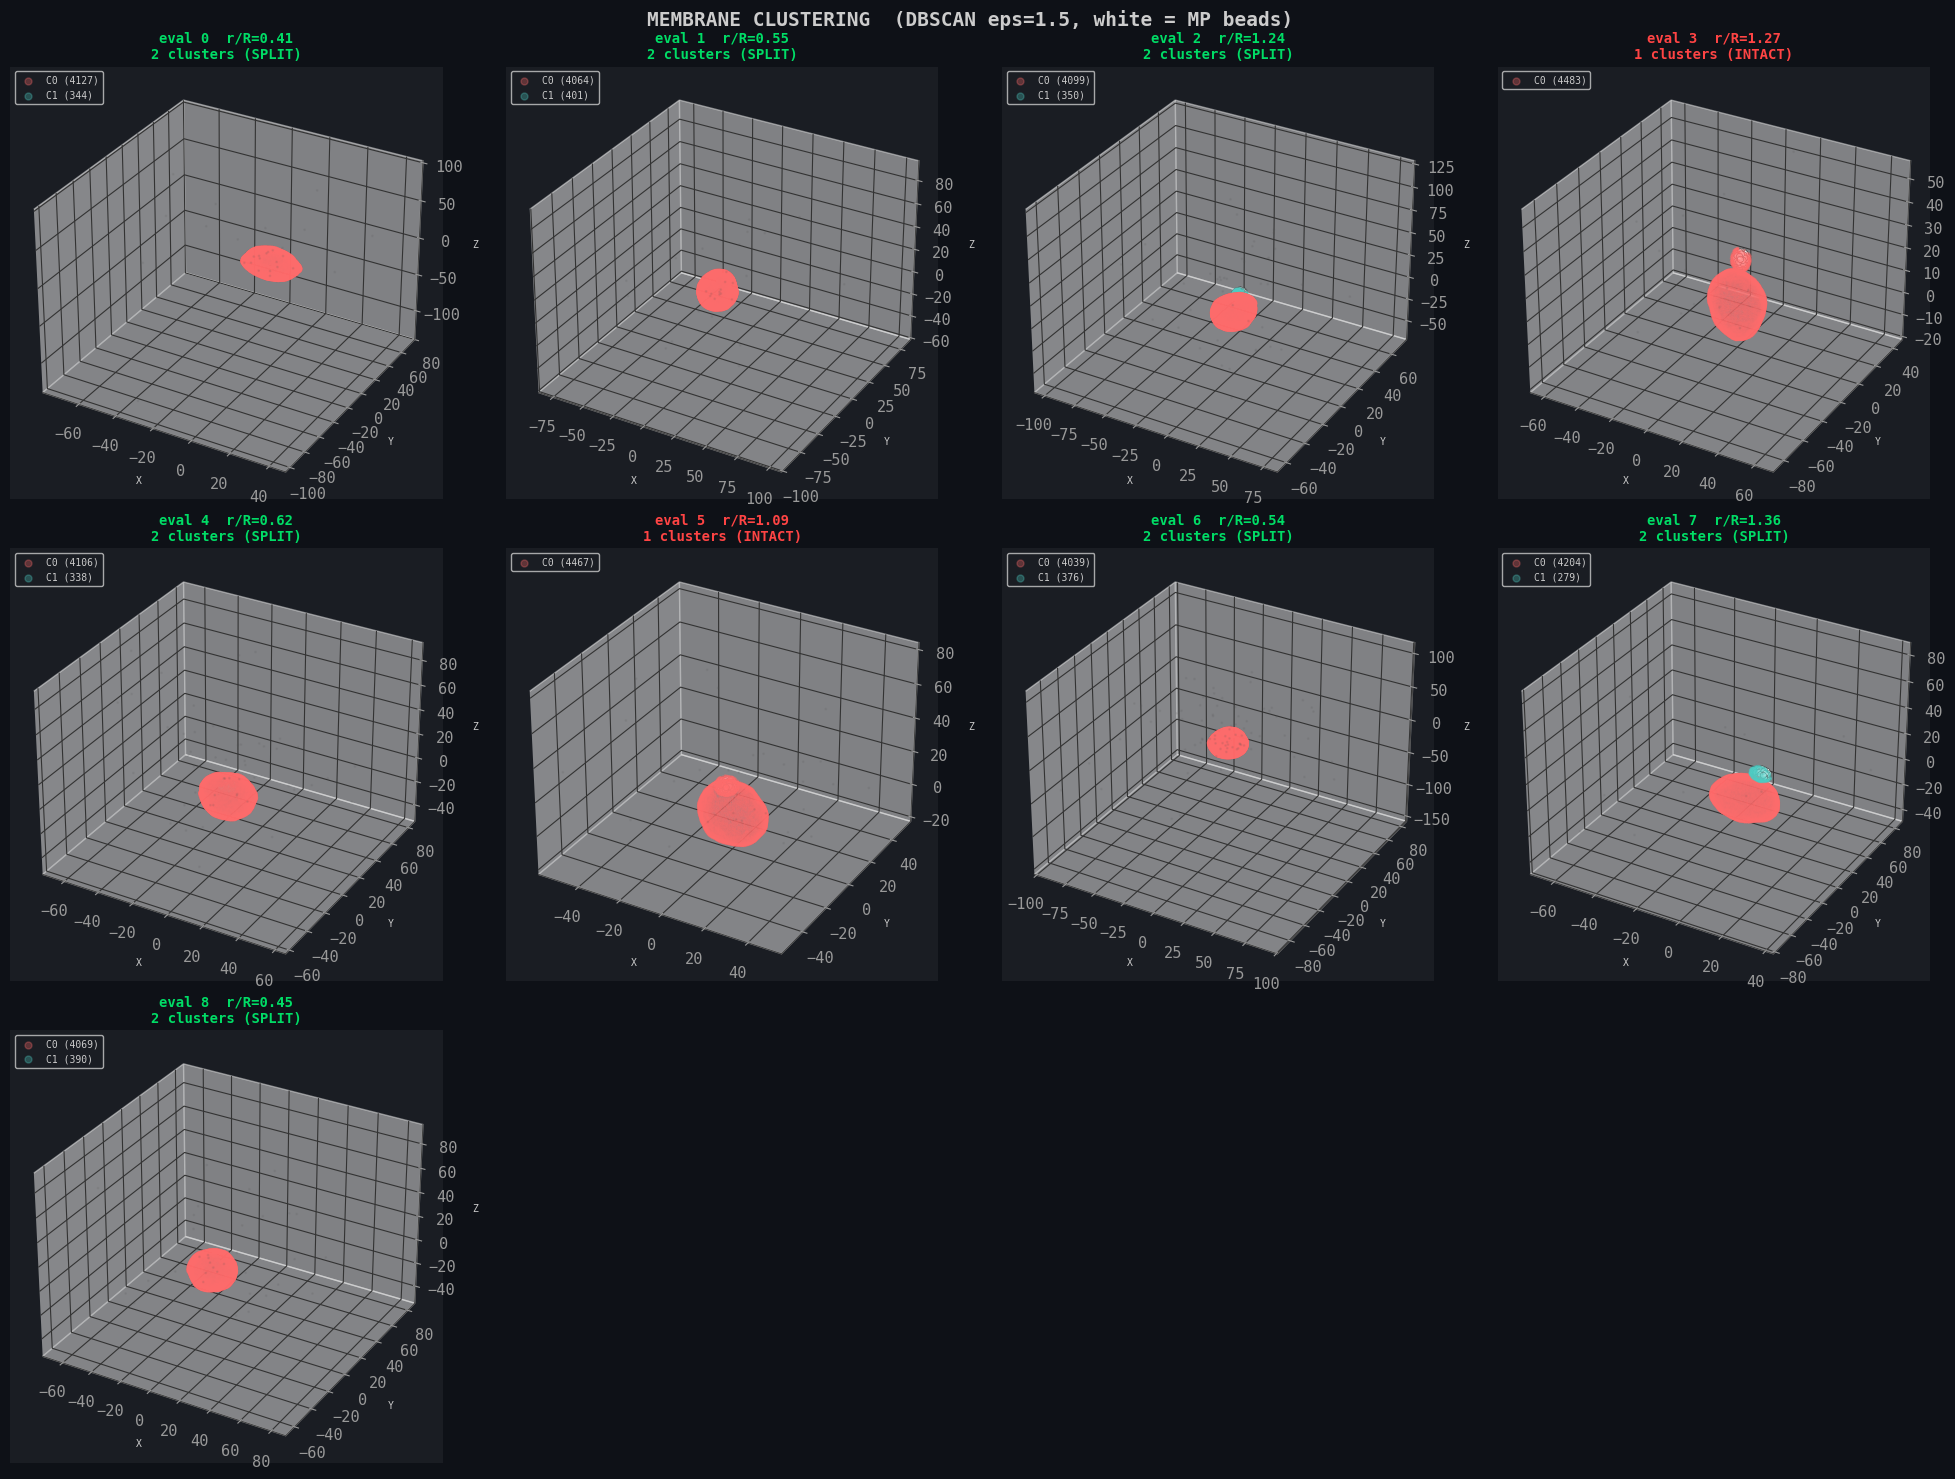

In [155]:
# 3D CLUSTER VISUALIZATION: one subplot per run
# Membrane beads colored by DBSCAN cluster. MP beads in white.
# Shows whether the membrane pocket separated from the main vesicle.

n_runs = len(cluster_data)
ncols = 4
nrows = int(np.ceil(n_runs / ncols))

fig = plt.figure(figsize=(5 * ncols, 5 * nrows))

cluster_cmap = ["#ff6b6b", "#4ecdc4", "#ffe66d", "#a855f7", "#f97316"]

for i, cd in enumerate(cluster_data):
    if cd["n_clusters"] is None:
        continue

    ax = fig.add_subplot(nrows, ncols, i + 1, projection="3d")
    ax.set_facecolor("#1a1d23")

    mem_pos = cd["mem_pos"]
    mp_pos = cd["mp_pos"]
    labels = cd["labels"]
    eid = cd["eval_id"]
    n_cl = cd["n_clusters"]
    rr = ok[i]["radial_ratio"]
    s = ok[i]["objective"]

    # Plot each membrane cluster in a different color
    unique_labels = sorted(set(labels) - {-1})
    for k, lbl in enumerate(unique_labels):
        mask = labels == lbl
        color = cluster_cmap[k % len(cluster_cmap)]
        size = mask.sum()
        ax.scatter(mem_pos[mask, 0], mem_pos[mask, 1], mem_pos[mask, 2],
                   c=color, s=1, alpha=0.3, label=f"C{k} ({size})")

    # Noise points
    noise_mask = labels == -1
    if noise_mask.sum() > 0:
        ax.scatter(mem_pos[noise_mask, 0], mem_pos[noise_mask, 1], mem_pos[noise_mask, 2],
                   c="#555", s=1, alpha=0.1)

    # MP beads
    ax.scatter(mp_pos[:, 0], mp_pos[:, 1], mp_pos[:, 2],
               c="white", s=20, edgecolors="black", linewidths=0.3, zorder=10)

    split_str = "SPLIT" if n_cl >= 2 else "INTACT"
    border_color = "#00dd66" if n_cl >= 2 else "#ff4444"
    ax.set_title(f"eval {eid}  r/R={rr:.2f}\n{n_cl} clusters ({split_str})",
                 fontsize=10, fontweight="bold", color=border_color)
    ax.legend(fontsize=7, loc="upper left", markerscale=5)

    ax.set_xlabel("X", fontsize=7)
    ax.set_ylabel("Y", fontsize=7)
    ax.set_zlabel("Z", fontsize=7)

fig.suptitle(f"MEMBRANE CLUSTERING  (DBSCAN eps={DBSCAN_EPS}, white = MP beads)",
             fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

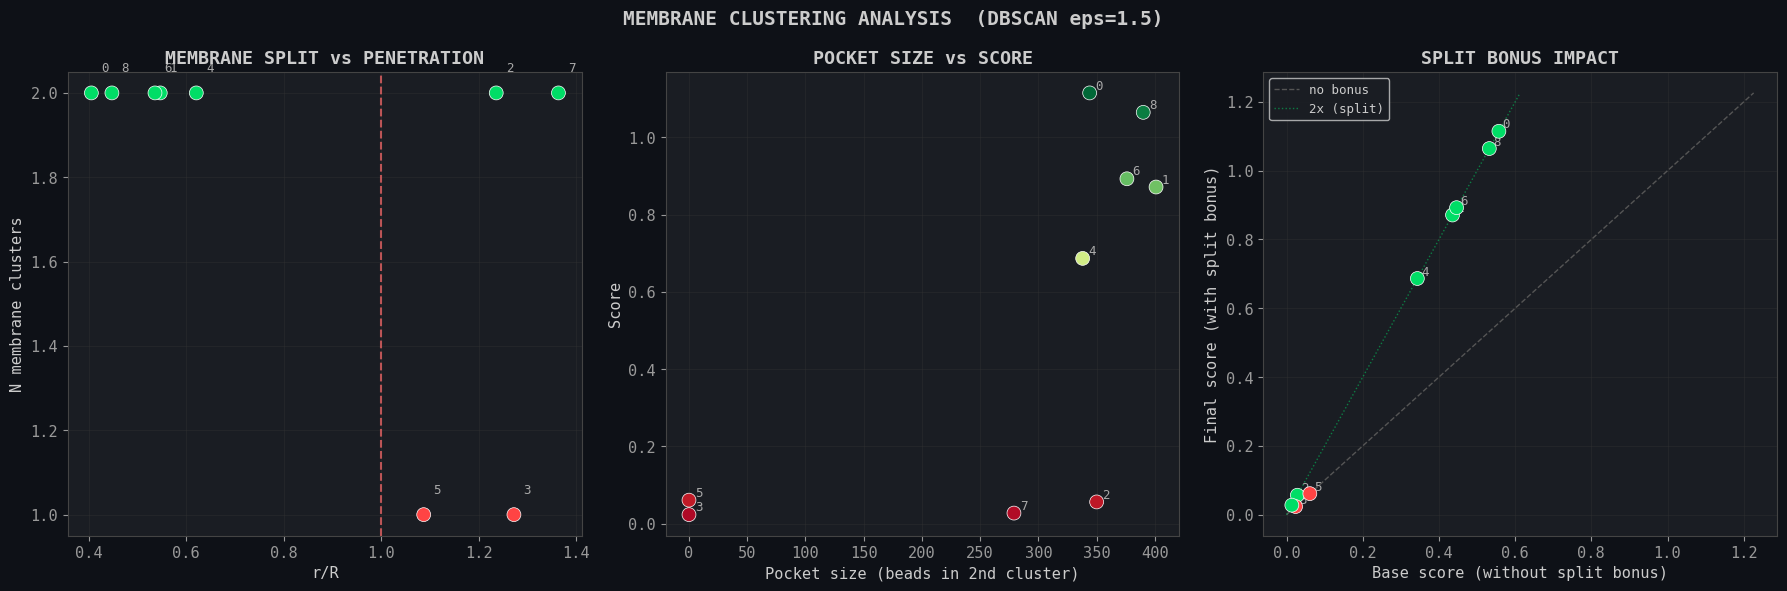

In [156]:
# CLUSTER SUMMARY: n_clusters vs score, and pocket size vs score

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

valid = [c for c in cluster_data if c["n_clusters"] is not None]
v_ncl = np.array([c["n_clusters"] for c in valid])
v_eid = np.array([c["eval_id"] for c in valid])
v_scores = np.array([ok[i]["objective"] for i in range(len(valid))])
v_rR = np.array([ok[i]["radial_ratio"] for i in range(len(valid))])
v_eps = np.array([ok[i]["epsilons"] for i in range(len(valid))])

v_pocket = np.array([c["cluster_sizes"][1] if len(c["cluster_sizes"]) > 1 else 0
                      for c in valid])

# --- LEFT: n_clusters vs r/R ---
colors_cl = ["#ff4444" if n == 1 else "#00dd66" for n in v_ncl]
ax1.scatter(v_rR, v_ncl, c=colors_cl, s=100, edgecolors="white", linewidths=0.5, zorder=5)
for k in range(len(valid)):
    ax1.text(v_rR[k] + 0.02, v_ncl[k] + 0.05, str(v_eid[k]),
             fontsize=9, color="#aaa")
ax1.axvline(1.0, color="#ff6b6b", ls="--", alpha=0.7)
ax1.set_xlabel("r/R")
ax1.set_ylabel("N membrane clusters")
ax1.set_title("MEMBRANE SPLIT vs PENETRATION", fontweight="bold")
ax1.grid(True)

# --- CENTER: pocket size vs score ---
sc = ax2.scatter(v_pocket, v_scores, c=v_scores, cmap="RdYlGn", s=100,
                 edgecolors="white", linewidths=0.5, vmin=0, vmax=score_max, zorder=5)
for k in range(len(valid)):
    ax2.text(v_pocket[k] + 5, v_scores[k] + 0.01, str(v_eid[k]),
             fontsize=9, color="#aaa")
ax2.set_xlabel("Pocket size (beads in 2nd cluster)")
ax2.set_ylabel("Score")
ax2.set_title("POCKET SIZE vs SCORE", fontweight="bold")
ax2.grid(True)

# --- RIGHT: score with vs without split bonus ---
base_scores = v_scores / np.where(v_ncl >= 2, 2.0, 1.0)
ax3.scatter(base_scores, v_scores, c=colors_cl, s=100,
            edgecolors="white", linewidths=0.5, zorder=5)
for k in range(len(valid)):
    ax3.text(base_scores[k] + 0.01, v_scores[k] + 0.01, str(v_eid[k]),
             fontsize=9, color="#aaa")
max_val = max(v_scores.max(), base_scores.max()) * 1.1
ax3.plot([0, max_val], [0, max_val], color="#555", ls="--", lw=1, label="no bonus")
ax3.plot([0, max_val / 2], [0, max_val], color="#00dd66", ls=":", lw=1, alpha=0.5, label="2x (split)")
ax3.set_xlabel("Base score (without split bonus)")
ax3.set_ylabel("Final score (with split bonus)")
ax3.set_title("SPLIT BONUS IMPACT", fontweight="bold")
ax3.legend(fontsize=9)
ax3.grid(True)

fig.suptitle(f"MEMBRANE CLUSTERING ANALYSIS  (DBSCAN eps={DBSCAN_EPS})",
             fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()